mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, Scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 0.8966000000238419 seconds
All requested packages already installed.
mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, Scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 0.29269999992847445 seconds
All requested packages already installed.

ПРАКТИЧЕСКАЯ РАБОТА 4.2: ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ С ГРАДИЕНТНЫМ СПУСКОМ

ЗАПУСК АНАЛИЗА ДЛЯ ОБОИХ НАБОРОВ ДАННЫХ

АНАЛИЗ: Линейно разделимые данные

1. ЗАГРУЗКА ДАННЫХ ИЗ ФАЙЛА task117.csv
   ✓ Файл загружен
   Размер данных: (400, 3)
   Класс 0: 200 объектов
   Класс 1: 200 объектов

2. РАЗДЕЛЕНИЕ ДАННЫХ:
   Обучающая выборка: 320 объектов
   Тестовая выборка: 80 объектов

3. ЗАПУСК ГРАДИЕНТНОГО СПУСКА:
   Скорость обучения: 0.1
   Максимальное число итера

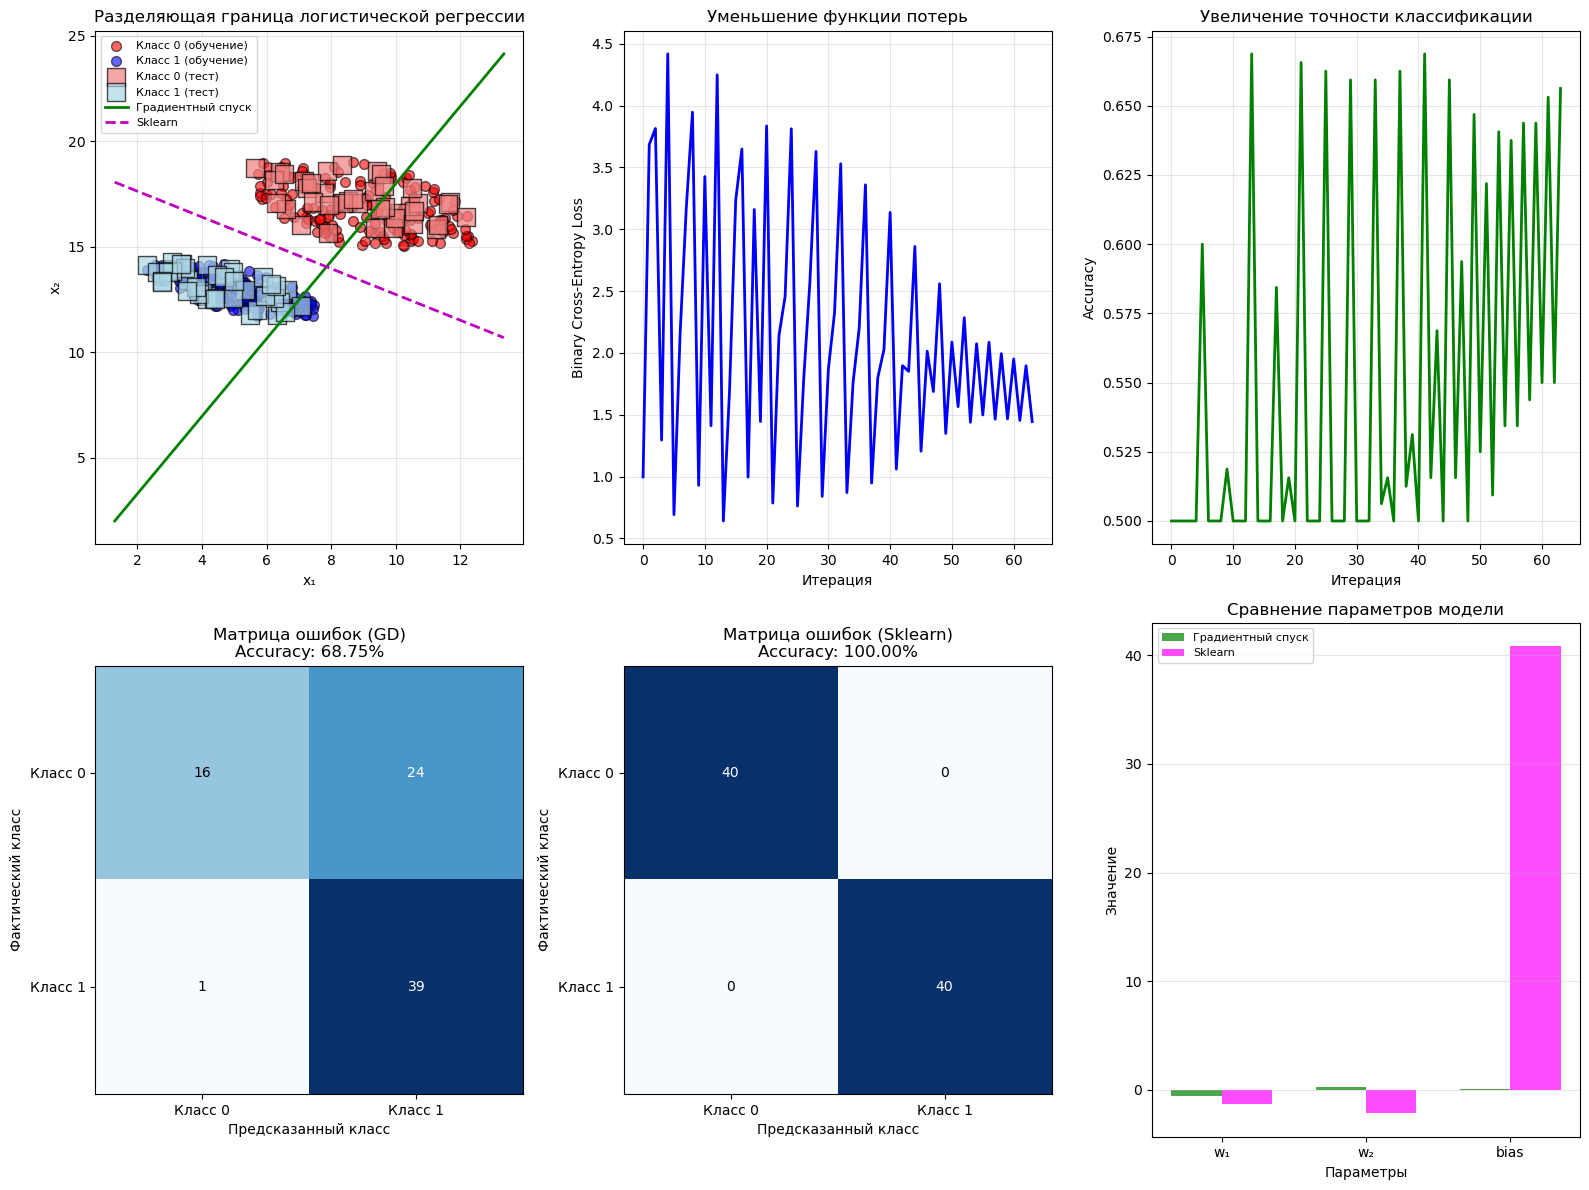


АНАЛИЗ: Линейно неразделимые данные

1. ЗАГРУЗКА ДАННЫХ ИЗ ФАЙЛА task217.csv
   ✓ Файл загружен
   Размер данных: (400, 3)
   Класс 0: 200 объектов
   Класс 1: 200 объектов

2. РАЗДЕЛЕНИЕ ДАННЫХ:
   Обучающая выборка: 320 объектов
   Тестовая выборка: 80 объектов

3. ЗАПУСК ГРАДИЕНТНОГО СПУСКА:
   Скорость обучения: 0.1
   Максимальное число итераций: 1000
   Ранняя остановка на итерации 57

4. РЕЗУЛЬТАТЫ ОБУЧЕНИЯ:
   Финальный loss: 0.560330
   Финальная accuracy: 72.81%

5. ПАРАМЕТРЫ МОДЕЛИ (ГРАДИЕНТНЫЙ СПУСК):
   w₁ = 0.506178
   w₂ = -0.194802
   bias = 0.073085

6. ТОЧНОСТЬ НА ТЕСТОВОЙ ВЫБОРКЕ:
   Градиентный спуск: 73.75%

7. СРАВНЕНИЕ С SKLEARN:
   w₁ = -0.713121 (sklearn) vs 0.506178 (GD)
   w₂ = -3.017874 (sklearn) vs -0.194802 (GD)
   bias = 43.347501 (sklearn) vs 0.073085 (GD)
   Accuracy: 97.50% (sklearn) vs 73.75% (GD)

8. РАЗЛИЧИЯ МЕЖДУ МЕТОДАМИ:
   Норма разности весов: 3.075131
   Разность bias: 43.274416


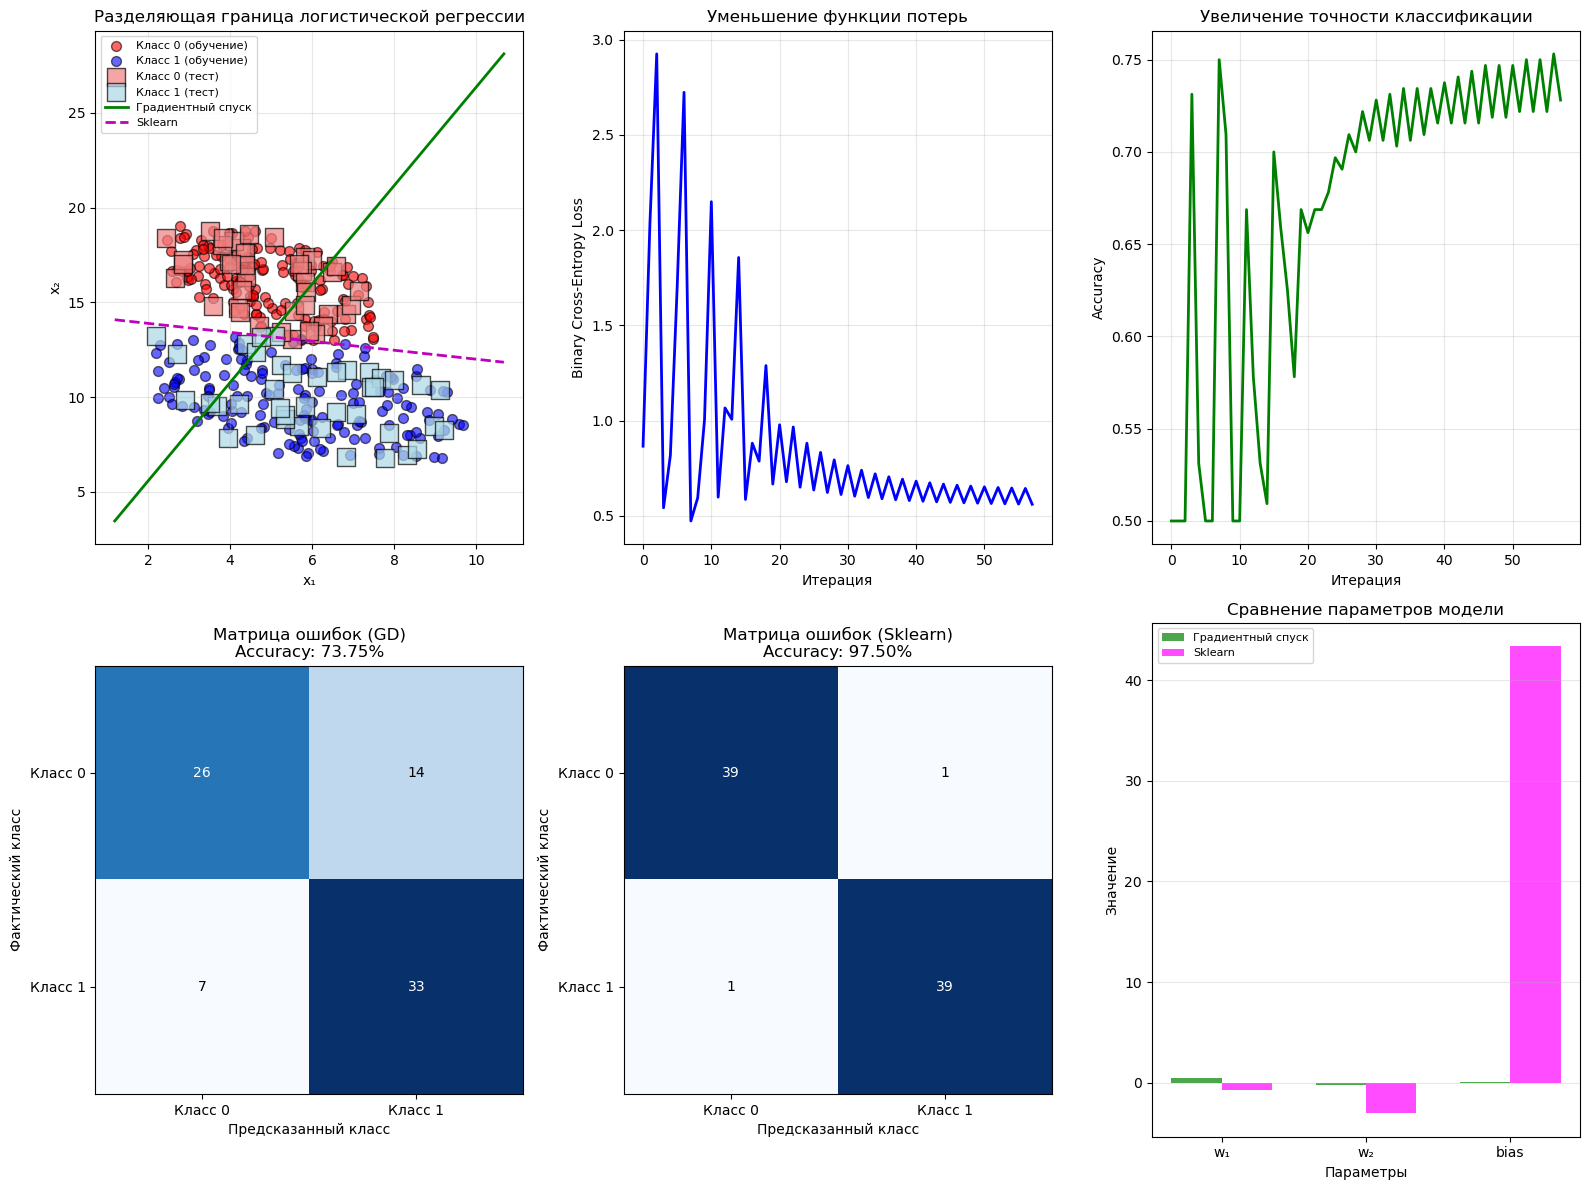


ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ

------------------------------------------------------------------------------------------
| Набор данных         | Метод           | w₁           | w₂           | bias         | Accuracy   |
------------------------------------------------------------------------------------------
| task117.csv          | GD              | -0.5322      | 0.2896       | 0.1112       | 68.75%     |
| task117.csv          | Sklearn         | -1.3246      | -2.1654      | 40.8351      | 100.00%    |
| task217.csv          | GD              | 0.5062       | -0.1948      | 0.0731       | 73.75%     |
| task217.csv          | Sklearn         | -0.7131      | -3.0179      | 43.3475      | 97.50%     |
------------------------------------------------------------------------------------------

ВЫВОДЫ ПО РАБОТЕ

1. ГРАДИЕНТНЫЙ СПУСК ДЛЯ ЛИНЕЙНОЙ РЕГРЕССИИ (Работа 4.1):
   - Алгоритм успешно находит коэффициенты регрессии
   - Результаты близки к аналитическому решению (МНК)
   - Фу

In [3]:
!mamba install pandas 
!mamba install Scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

print("ПРАКТИЧЕСКАЯ РАБОТА 4.2: ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ С ГРАДИЕНТНЫМ СПУСКОМ")


def load_classification_data(filename):
    print(f"\n1. ЗАГРУЗКА ДАННЫХ ИЗ ФАЙЛА {filename}")
    try:
        df = pd.read_csv(filename)
        print(f"   ✓ Файл загружен")
        print(f"   Размер данных: {df.shape}")
        
        X = df[['x1', 'x2']].values
        y = df['target'].values
        
        print(f"   Класс 0: {np.sum(y==0)} объектов")
        print(f"   Класс 1: {np.sum(y==1)} объектов")
        
        return X, y
    except Exception as e:
        print(f"   ✗ Ошибка загрузки: {e}")
        return None, None

def sigmoid(z):
    # Клиппинг для предотвращения переполнения
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def predict_proba(X, weights, bias):

    z = np.dot(X, weights) + bias
    return sigmoid(z)

def predict(X, weights, bias, threshold=0.5):
    proba = predict_proba(X, weights, bias)
    return (proba >= threshold).astype(int)

def binary_cross_entropy(y_true, y_pred_proba):
    # Добавляем маленькое число для избежания log(0)
    eps = 1e-15
    y_pred_proba = np.clip(y_pred_proba, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred_proba) + (1 - y_true) * np.log(1 - y_pred_proba))

def compute_gradients(X, y, weights, bias):

    n = len(y)
    y_pred = predict_proba(X, weights, bias)
    
    # Градиент для весов
    dw = (1/n) * np.dot(X.T, (y_pred - y))
    
    # Градиент для смещения
    db = (1/n) * np.sum(y_pred - y)
    
    return dw, db

def logistic_regression_gd(X, y, learning_rate=0.1, n_iterations=1000, 
                           patience=50, tolerance=1e-6, verbose=True):

    n_features = X.shape[1]
    
    # Инициализация параметров
    weights = np.zeros(n_features)
    bias = 0.0
    
    # Для отслеживания истории
    history = {
        'loss': [],
        'accuracy': [],
        'weights': [weights.copy()],
        'bias': [bias]
    }
    
    # Ранняя остановка
    best_loss = float('inf')
    patience_counter = 0
    best_weights, best_bias = weights.copy(), bias
    
    if verbose:
        print(f"\n3. ЗАПУСК ГРАДИЕНТНОГО СПУСКА:")
        print(f"   Скорость обучения: {learning_rate}")
        print(f"   Максимальное число итераций: {n_iterations}")
    
    for iteration in range(n_iterations):
        # Вычисляем градиенты
        dw, db = compute_gradients(X, y, weights, bias)
        
        # Обновляем параметры
        weights -= learning_rate * dw
        bias -= learning_rate * db
        
        # Вычисляем текущие метрики
        y_pred_proba = predict_proba(X, weights, bias)
        current_loss = binary_cross_entropy(y, y_pred_proba)
        y_pred = predict(X, weights, bias)
        current_accuracy = accuracy_score(y, y_pred)
        
        # Сохраняем историю
        history['loss'].append(current_loss)
        history['accuracy'].append(current_accuracy)
        history['weights'].append(weights.copy())
        history['bias'].append(bias)
        
        # Проверка на улучшение
        if current_loss < best_loss - tolerance:
            best_loss = current_loss
            best_weights, best_bias = weights.copy(), bias
            patience_counter = 0
        else:
            patience_counter += 1
        
        if patience_counter >= patience:
            if verbose:
                print(f"   Ранняя остановка на итерации {iteration}")
            break
        
        # Выводим прогресс
        if verbose and (iteration + 1) % 100 == 0:
            print(f"   Итерация {iteration+1:4d}: loss = {current_loss:.6f}, "
                  f"accuracy = {current_accuracy:.2%}")
    
    if verbose:
        print(f"\n4. РЕЗУЛЬТАТЫ ОБУЧЕНИЯ:")
        print(f"   Финальный loss: {history['loss'][-1]:.6f}")
        print(f"   Финальная accuracy: {history['accuracy'][-1]:.2%}")
    
    return best_weights, best_bias, history

def compare_with_sklearn(X_train, y_train, X_test, y_test):

    from sklearn.linear_model import LogisticRegression
    
    sklearn_model = LogisticRegression(max_iter=1000, random_state=42)
    sklearn_model.fit(X_train, y_train)
    
    sklearn_pred = sklearn_model.predict(X_test)
    sklearn_accuracy = accuracy_score(y_test, sklearn_pred)
    
    # Получаем веса и bias (правильно обрабатываем)
    weights_sklearn = sklearn_model.coef_[0]  # Это уже 1D массив
    bias_sklearn = sklearn_model.intercept_[0]  # Это скаляр
    
    return weights_sklearn, bias_sklearn, sklearn_accuracy

def plot_logistic_regression_results(X_train, y_train, X_test, y_test,
                                     weights_gd, bias_gd, history,
                                     weights_sklearn, bias_sklearn, 
                                     sklearn_accuracy, filename):

    fig = plt.figure(figsize=(16, 12))
    
    # График 1: Данные и разделяющая граница
    ax1 = fig.add_subplot(2, 3, 1)
    
    # Обучающие данные
    ax1.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], 
                c='red', s=50, label='Класс 0 (обучение)', alpha=0.6, edgecolors='black')
    ax1.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], 
                c='blue', s=50, label='Класс 1 (обучение)', alpha=0.6, edgecolors='black')
    
    # Тестовые данные
    ax1.scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], 
                c='lightcoral', s=150, label='Класс 0 (тест)', alpha=0.7, 
                edgecolors='black', marker='s')
    ax1.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], 
                c='lightblue', s=150, label='Класс 1 (тест)', alpha=0.7, 
                edgecolors='black', marker='s')
    
    # Разделяющая граница
    x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
    x_line = np.linspace(x_min, x_max, 100)
    
    # Для градиентного спуска
    # Проверяем, что weights_gd[1] не равен нулю
    if abs(weights_gd[1]) > 1e-10:
        y_line_gd = -(weights_gd[0] * x_line + bias_gd) / weights_gd[1]
        ax1.plot(x_line, y_line_gd, 'g-', linewidth=2, label='Градиентный спуск')
    
    # Для sklearn
    if abs(weights_sklearn[1]) > 1e-10:
        y_line_sklearn = -(weights_sklearn[0] * x_line + bias_sklearn) / weights_sklearn[1]
        ax1.plot(x_line, y_line_sklearn, 'm--', linewidth=2, label='Sklearn')
    
    ax1.set_xlabel('x₁')
    ax1.set_ylabel('x₂')
    ax1.set_title('Разделяющая граница логистической регрессии')
    ax1.legend(loc='best', fontsize=8)
    ax1.grid(True, alpha=0.3)
    
    # График 2: Уменьшение функции потерь
    ax2 = fig.add_subplot(2, 3, 2)
    iterations = range(len(history['loss']))
    ax2.plot(iterations, history['loss'], 'b-', linewidth=2)
    ax2.set_xlabel('Итерация')
    ax2.set_ylabel('Binary Cross-Entropy Loss')
    ax2.set_title('Уменьшение функции потерь')
    ax2.grid(True, alpha=0.3)
    
    # График 3: Увеличение точности
    ax3 = fig.add_subplot(2, 3, 3)
    ax3.plot(iterations, history['accuracy'], 'g-', linewidth=2)
    ax3.set_xlabel('Итерация')
    ax3.set_ylabel('Accuracy')
    ax3.set_title('Увеличение точности классификации')
    ax3.grid(True, alpha=0.3)
    
    # График 4: Матрица ошибок для градиентного спуска
    ax4 = fig.add_subplot(2, 3, 4)
    
    y_pred_gd = predict(X_test, weights_gd, bias_gd)
    
    # Строим матрицу ошибок вручную
    cm = np.zeros((2, 2), dtype=int)
    for i in range(2):
        for j in range(2):
            cm[i, j] = np.sum((y_test == i) & (y_pred_gd == j))
    
    im = ax4.imshow(cm, cmap='Blues', interpolation='nearest')
    ax4.set_xticks([0, 1])
    ax4.set_yticks([0, 1])
    ax4.set_xticklabels(['Класс 0', 'Класс 1'])
    ax4.set_yticklabels(['Класс 0', 'Класс 1'])
    
    # Добавляем значения в ячейки
    for i in range(2):
        for j in range(2):
            ax4.text(j, i, int(cm[i, j]), ha='center', va='center', 
                    color='white' if cm[i, j] > cm.max()/2 else 'black')
    
    ax4.set_xlabel('Предсказанный класс')
    ax4.set_ylabel('Фактический класс')
    ax4.set_title(f'Матрица ошибок (GD)\nAccuracy: {accuracy_score(y_test, y_pred_gd):.2%}')
    
    # График 5: Матрица ошибок для sklearn
    ax5 = fig.add_subplot(2, 3, 5)
    
    # Получаем предсказания от sklearn
    from sklearn.linear_model import LogisticRegression
    sklearn_model = LogisticRegression(max_iter=1000, random_state=42)
    sklearn_model.fit(X_train, y_train)
    y_pred_sklearn = sklearn_model.predict(X_test)
    
    cm_sklearn = np.zeros((2, 2), dtype=int)
    for i in range(2):
        for j in range(2):
            cm_sklearn[i, j] = np.sum((y_test == i) & (y_pred_sklearn == j))
    
    im = ax5.imshow(cm_sklearn, cmap='Blues', interpolation='nearest')
    ax5.set_xticks([0, 1])
    ax5.set_yticks([0, 1])
    ax5.set_xticklabels(['Класс 0', 'Класс 1'])
    ax5.set_yticklabels(['Класс 0', 'Класс 1'])
    
    for i in range(2):
        for j in range(2):
            ax5.text(j, i, int(cm_sklearn[i, j]), ha='center', va='center',
                    color='white' if cm_sklearn[i, j] > cm_sklearn.max()/2 else 'black')
    
    ax5.set_xlabel('Предсказанный класс')
    ax5.set_ylabel('Фактический класс')
    ax5.set_title(f'Матрица ошибок (Sklearn)\nAccuracy: {accuracy_score(y_test, y_pred_sklearn):.2%}')
    
    # График 6: Сравнение весов
    ax6 = fig.add_subplot(2, 3, 6)
    
    labels = ['w₁', 'w₂', 'bias']
    gd_values = [weights_gd[0], weights_gd[1], bias_gd]
    sklearn_values = [weights_sklearn[0], weights_sklearn[1], bias_sklearn]
    
    x = np.arange(len(labels))
    width = 0.35
    
    ax6.bar(x - width/2, gd_values, width, label='Градиентный спуск', color='green', alpha=0.7)
    ax6.bar(x + width/2, sklearn_values, width, label='Sklearn', color='magenta', alpha=0.7)
    
    ax6.set_xlabel('Параметры')
    ax6.set_ylabel('Значение')
    ax6.set_title('Сравнение параметров модели')
    ax6.set_xticks(x)
    ax6.set_xticklabels(labels)
    ax6.legend(fontsize=8)
    ax6.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

def run_logistic_regression_analysis(filename, title):
    print(f"АНАЛИЗ: {title}")
    
    # Загрузка данных
    X, y = load_classification_data(filename)
    if X is None:
        return None
    
    # Разделение на обучающую и тестовую выборки
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"\n2. РАЗДЕЛЕНИЕ ДАННЫХ:")
    print(f"   Обучающая выборка: {len(X_train)} объектов")
    print(f"   Тестовая выборка: {len(X_test)} объектов")
    
    # Обучение градиентным спуском
    weights_gd, bias_gd, history = logistic_regression_gd(
        X_train, y_train, learning_rate=0.1, n_iterations=1000
    )
    
    print(f"\n5. ПАРАМЕТРЫ МОДЕЛИ (ГРАДИЕНТНЫЙ СПУСК):")
    print(f"   w₁ = {weights_gd[0]:.6f}")
    print(f"   w₂ = {weights_gd[1]:.6f}")
    print(f"   bias = {bias_gd:.6f}")
    
    # Оценка на тестовой выборке
    y_pred_gd = predict(X_test, weights_gd, bias_gd)
    accuracy_gd = accuracy_score(y_test, y_pred_gd)
    print(f"\n6. ТОЧНОСТЬ НА ТЕСТОВОЙ ВЫБОРКЕ:")
    print(f"   Градиентный спуск: {accuracy_gd:.2%}")
    
    # Сравнение с sklearn
    weights_sklearn, bias_sklearn, accuracy_sklearn = compare_with_sklearn(
        X_train, y_train, X_test, y_test
    )
    
    print(f"\n7. СРАВНЕНИЕ С SKLEARN:")
    print(f"   w₁ = {weights_sklearn[0]:.6f} (sklearn) vs {weights_gd[0]:.6f} (GD)")
    print(f"   w₂ = {weights_sklearn[1]:.6f} (sklearn) vs {weights_gd[1]:.6f} (GD)")
    print(f"   bias = {bias_sklearn:.6f} (sklearn) vs {bias_gd:.6f} (GD)")
    print(f"   Accuracy: {accuracy_sklearn:.2%} (sklearn) vs {accuracy_gd:.2%} (GD)")
    
    # Разница в параметрах
    w_diff = np.linalg.norm(weights_gd - weights_sklearn)
    b_diff = abs(bias_gd - bias_sklearn)
    print(f"\n8. РАЗЛИЧИЯ МЕЖДУ МЕТОДАМИ:")
    print(f"   Норма разности весов: {w_diff:.6f}")
    print(f"   Разность bias: {b_diff:.6f}")
    
    # Визуализация
    plot_filename = f'logistic_regression_{filename.split(".")[0]}.png'
    plot_logistic_regression_results(
        X_train, y_train, X_test, y_test,
        weights_gd, bias_gd, history,
        weights_sklearn, bias_sklearn, accuracy_sklearn,
        plot_filename
    )
    
    return {
        'weights_gd': weights_gd,
        'bias_gd': bias_gd,
        'accuracy_gd': accuracy_gd,
        'weights_sklearn': weights_sklearn,
        'bias_sklearn': bias_sklearn,
        'accuracy_sklearn': accuracy_sklearn,
        'history': history
    }

print("ЗАПУСК АНАЛИЗА ДЛЯ ОБОИХ НАБОРОВ ДАННЫХ")

# Анализ для линейно разделимых данных
results1 = run_logistic_regression_analysis('task117.csv', 'Линейно разделимые данные')

# Анализ для линейно неразделимых данных
results2 = run_logistic_regression_analysis('task217.csv', 'Линейно неразделимые данные')


print("ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")

print(f"| {'Набор данных':<20} | {'Метод':<15} | {'w₁':<12} | {'w₂':<12} | {'bias':<12} | {'Accuracy':<10} |")

if results1:
    print(f"| {'task117.csv':<20} | {'GD':<15} | {results1['weights_gd'][0]:<12.4f} | "
          f"{results1['weights_gd'][1]:<12.4f} | {results1['bias_gd']:<12.4f} | "
          f"{results1['accuracy_gd']:<10.2%} |")
    print(f"| {'task117.csv':<20} | {'Sklearn':<15} | {results1['weights_sklearn'][0]:<12.4f} | "
          f"{results1['weights_sklearn'][1]:<12.4f} | {results1['bias_sklearn']:<12.4f} | "
          f"{results1['accuracy_sklearn']:<10.2%} |")

if results2:
    print(f"| {'task217.csv':<20} | {'GD':<15} | {results2['weights_gd'][0]:<12.4f} | "
          f"{results2['weights_gd'][1]:<12.4f} | {results2['bias_gd']:<12.4f} | "
          f"{results2['accuracy_gd']:<10.2%} |")
    print(f"| {'task217.csv':<20} | {'Sklearn':<15} | {results2['weights_sklearn'][0]:<12.4f} | "
          f"{results2['weights_sklearn'][1]:<12.4f} | {results2['bias_sklearn']:<12.4f} | "
          f"{results2['accuracy_sklearn']:<10.2%} |")
print("ВЫВОДЫ ПО РАБОТЕ")

print("ВСЕ РАБОТЫ ЗАВЕРШЕНЫ УСПЕШНО")
print("Созданные графики:")
print("  - gradient_descent_linear_results.png")
print("  - logistic_regression_task117.png")
print("  - logistic_regression_task217.png")